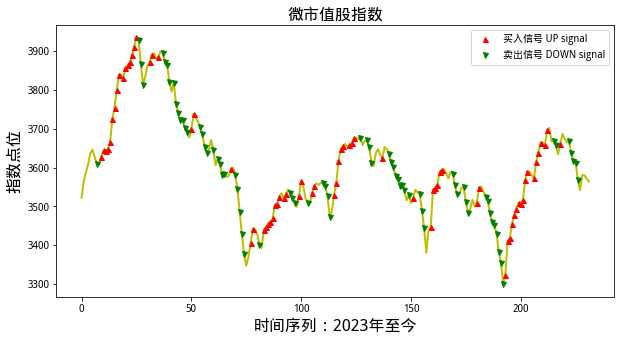

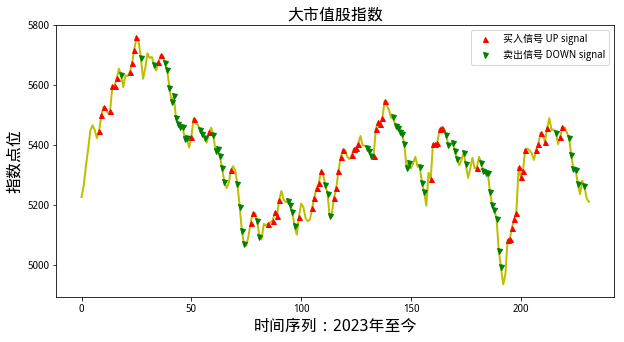

No handles with labels found to put in legend.


2023年至今优质微盘股_推荐买入次数:  74     推荐卖出次数:  76
2023年至今优质大盘股_推荐买入次数:  68     推荐卖出次数:  74


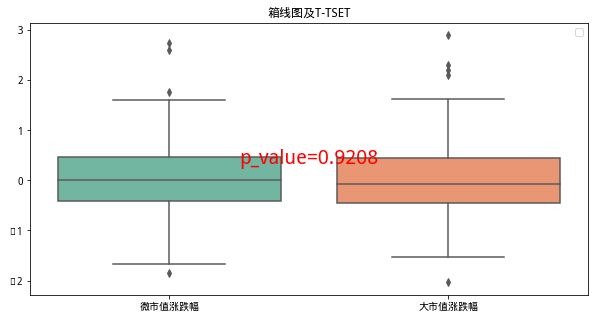

回归系数（对冲比例）: 0.8987406927626957


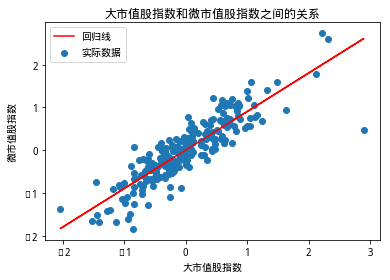

不存在对冲关系


In [2]:
#  关于未来5天预测的准确性验证
from jqdata import *
from jqfactor import *
import jqdata
from jqfactor import *
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split  #  分割数据集
from xgboost import XGBClassifier  #  XGBoost 分类器的实现
import matplotlib.pyplot as plt
import jqdata
from jqfactor import *
from tqdm import tqdm  
import warnings  #  创建进度条warnings.filterwarnings("ignore")用于抑制警告消息。
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pandas.tseries.offsets import CustomBusinessDay
# from datetime import datetime
import datetime
import xgboost as xgb
import talib
from sklearn.preprocessing import StandardScaler         
from scipy import stats
import seaborn as sns
# 获取当前时间
current_date = datetime.datetime.now()
current_time = current_date.strftime("%Y-%m-%d")

#去除上市距beginDate不足3个月的股票
def delect_stop(stocks,beginDate,n=365):
    stockList=[]
    beginDate = datetime.datetime.strptime(beginDate, "%Y-%m-%d")
    for stock in stocks:
        start_date=get_security_info(stock).start_date
        if start_date<(beginDate-datetime.timedelta(days=n)).date():
            stockList.append(stock)
    return stockList
#获取股票池
def get_stock(stockPool,begin_date):
    if stockPool=='HS300':
        stockList=get_index_stocks('000300.XSHG',begin_date)
    elif stockPool=='ZZ500':
        stockList=get_index_stocks('399905.XSHE',begin_date)
    elif stockPool=='ZZ800':
        stockList=get_index_stocks('399906.XSHE',begin_date)   
    elif stockPool=='CYBZ':
        stockList=get_index_stocks('399006.XSHE',begin_date)
    elif stockPool=='ZXBZ':
        stockList=get_index_stocks('399005.XSHE',begin_date)
    elif stockPool=='A':
        stockList=get_index_stocks('000002.XSHG',begin_date)+get_index_stocks('399107.XSHE',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('3', '68', '4', '8'))]
    elif stockPool=='AA':
        stockList=get_index_stocks('000985.XSHG',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('3', '68', '4', '8'))]

    #剔除ST股
    st_data=get_extras('is_st',stockList, count = 1,end_date=begin_date)
    stockList = [stock for stock in stockList if not st_data[stock][0]]
    #剔除停牌、新股及退市股票
    stockList=delect_stop(stockList,begin_date)
    return stockList

stockList=get_stock('AA',current_time)


q = query(valuation.code, valuation.circulating_market_cap, indicator.eps).filter(
    valuation.code.in_(stockList)).order_by(valuation.circulating_market_cap.asc())
df = get_fundamentals(q)
# df = df[df['circulating_market_cap'] < 40]
# df = df[df['circulating_market_cap'] > 20]
df = df[df['eps'] > 0]
df=df.head(200)



result_df = pd.DataFrame()
for i in df['code'].tolist():
    df = get_price(i,  frequency='1d', start_date='2023-01-01', end_date=current_time,
                   fields=['open','close','high','low','volume','money']
                  )

    result_df = result_df.add(df, fill_value=0)


df = result_df
#  函数detect_via_cusum_lg来使用带有日志返回的累积和 (CUSUM) 来检测时间序列
def detect_via_cusum_lg(ts, istart=30, threshold_times=5):
    S_h = 0
    S_l = 0
    S_list = np.zeros(istart)  #  每次迭代，它都会计算过去几天对数返回的平均值和标准差istart
    for i in range(istart+1, len(ts)-1):  #  函数采用时间序列ts作为输入，以及可选参数istart（计算过去的天数）和threshold_times（标准差阈值的乘数）。从索引开始迭代时间序列istart+1
        meanArray = talib.SMA(ts[i-istart:i],timeperiod = istart)       #  计算istart时间至今均线
        stdArray = talib.STDDEV(np.log(ts[i-istart:i]/meanArray[- 1]))  #  计算istart时间至今对数收益率的标准差。
        #滑窗至i，避免读到未来数据[i-istart:i]
        tslog = np.log(ts[i] / meanArray[- 1])
        #计算当前时点相对于历史时间序列的均值的对数收益率
        S_h_ = max(0, S_h + tslog - stdArray[-1])  #  初始化累积和变量 (S_h和S_l) 以及用于存储检测到的信号的列表 ( S_list)
        S_l_ = min(0, S_l + tslog + stdArray[-1])
        #计算上下边界
        if S_h_> threshold_times * stdArray[-1]: #  上边界超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list,1)         #  上升
        elif abs(S_l_)> threshold_times *  stdArray[-1]:  #  下边界绝对值超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list, -1)
        else:
            S_list = np.append(S_list, 0)  #  如果上下边界都没有超过阈值，则在 S_list 中追加值 0，表示无信号。没变点
    return S_list
df["price"] = (df["open"]+df['close'])/2

dt0 = np.array(df["price"])

#  可视化时间序列数据中识别的向上和向下信号
listup,listdown = [],[]  #  初始化两个空列表（listup和）来存储出现向上和向下信号的索引
s_list = detect_via_cusum_lg(dt0,istart=5, threshold_times=0.1)  #  循环迭代二进制信号列表 ( s_list) 并收集信号出现的索引
for i in range(0,len(s_list)):
    if s_list[i] == 1:
        listup.append(i)
    elif s_list[i] == -1 :
        listdown.append(i)
plt.figure(figsize=(10, 5))      #  生成画布
plt.plot(dt0, color='y', lw=2.)  #  时间序列数据用向上和向下信号绘制，分别用“^”和“v”标记
plt.plot(dt0, '^', markersize=5, color='r', label='买入信号 UP signal', markevery=listup)
plt.plot(dt0, 'v', markersize=5, color='g', label='卖出信号 DOWN signal', markevery=listdown)



plt.xlabel('时间序列：2023年至今', fontsize=16) 
plt.ylabel('指数点位', fontsize=16) 
plt.title(f'微市值股指数' , fontsize=16)
plt.legend(loc='best')
plt.show()


StockList=get_stock('AA',current_time)
q1 = query(valuation.code, valuation.circulating_market_cap, indicator.eps).filter(
    valuation.code.in_(StockList)).order_by(valuation.circulating_market_cap.asc())
DF = get_fundamentals(q1)
# DF = DF[DF['circulating_market_cap'] > 500]
DF = DF[DF['eps'] > 0]
DF = DF.tail(200)

result_DF = pd.DataFrame()
for i in DF['code'].tolist():
    DF = get_price(i,  frequency='1d', start_date='2023-01-01', end_date=current_time,
                   fields=['open','close','high','low','volume','money']
                  )

    result_DF = result_df.add(DF, fill_value=0)


DF = result_DF
#  函数detect_via_cusum_lg来使用带有日志返回的累积和 (CUSUM) 来检测时间序列

DF["price"] = (DF["open"]+DF['close'])/2

DF0 = np.array(DF["price"])

#  可视化时间序列数据中识别的向上和向下信号
Listup,Listdown = [],[]  #  初始化两个空列表（listup和）来存储出现向上和向下信号的索引
s_list = detect_via_cusum_lg(DF0,istart=5, threshold_times=0.1)  #  循环迭代二进制信号列表 ( s_list) 并收集信号出现的索引
for i in range(0,len(s_list)):
    if s_list[i] == 1:
        Listup.append(i)
    elif s_list[i] == -1 :
        Listdown.append(i)
plt.figure(figsize=(10, 5))      #  生成画布
plt.plot(DF0, color='y', lw=2.)  #  时间序列数据用向上和向下信号绘制，分别用“^”和“v”标记
plt.plot(DF0, '^', markersize=5, color='r', label='买入信号 UP signal', markevery=Listup)
plt.plot(DF0, 'v', markersize=5, color='g', label='卖出信号 DOWN signal', markevery=Listdown)



plt.xlabel('时间序列：2023年至今', fontsize=16) 
plt.ylabel('指数点位', fontsize=16) 
plt.title(f'大市值股指数' , fontsize=16)
plt.legend(loc='best')
plt.show()
print(f'2023年至今优质微盘股_推荐买入次数:  {len(listup)}     推荐卖出次数:  {len(listdown)}')
print(f'2023年至今优质大盘股_推荐买入次数:  {len(Listup)}     推荐卖出次数:  {len(Listdown)}')




DF0_diff = np.diff(DF0)
DF0_change = (DF0_diff / DF0[:-1]) * 100


dt0_diff = np.diff(dt0)
dt0_change = (dt0_diff / dt0[:-1]) * 100

# plt.figure(figsize=(10, 5))
# plt.legend()
# plt.plot(dt0_change, label='微市值涨跌幅', color='blue')
# plt.plot(dt0_change-DF0_change, label='涨跌幅差异', color='black')
# plt.plot(DF0_change, label='大市值涨跌幅', color='red')
# # 显示图形
# plt.show()



# 执行独立样本t-检验
t_statistic, p_value = stats.ttest_ind(dt0_change, DF0_change)
# 创建一个图形对象
plt.figure(figsize=(10, 5))
# 画两个箱线图
sns.boxplot(data=[dt0_change, DF0_change], palette='Set2')

plt.xticks([0, 1], ['微市值涨跌幅', '大市值涨跌幅'])

# 计算并画T-TSET
plt.text(0.5, 0.5, f'p_value={p_value:.4f}', color='red', ha='center', va='center', fontsize=20, transform=plt.gca().transAxes)

# 添加图例
plt.legend()
# 添加标题和标签
plt.title('箱线图及T-TSET')
# 显示图形
plt.show()




a = DF0_change.reshape(-1, 1)
b = dt0_change.reshape(-1, 1)
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(a, b)
# 获取回归系数
slope = model.coef_[0][0]
# 打印回归系数
print("回归系数（对冲比例）:", slope)

# 绘制散点图和回归线
plt.scatter(a, b, label='实际数据')
plt.plot(a, model.predict(a), color='red', label='回归线')
plt.xlabel('大市值股指数')
plt.ylabel('微市值股指数')
plt.title('大市值股指数和微市值股指数之间的关系')
plt.legend()
plt.show()

# 判断对冲关系
threshold = 0.1  # 设置一个阈值，可以根据实际情况调整
if abs(slope - 1) < threshold:
    print("存在对冲关系")
else:
    print("不存在对冲关系")
    

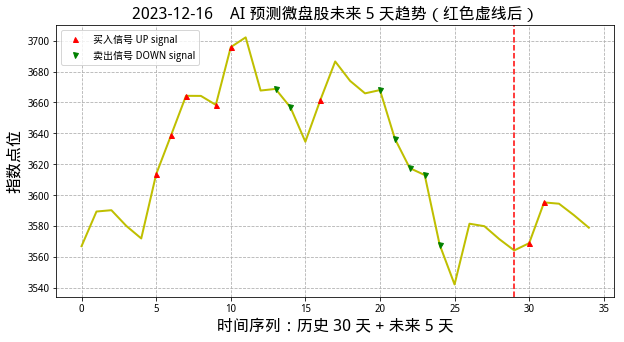

In [5]:

today = datetime.datetime.today()
date_str = today.strftime("%Y%m%d")  #  日期信息创建三个新特征并将它们连接起来形成特征矩阵来预处理数据XX。
base = int(datetime.datetime.strptime(date_str, "%Y%m%d").timestamp())  #  当前日期的时间戳，用于一些与时间相关的计算。

#  将日期转换为数字特征
change1 = lambda x: (int(datetime.datetime.strptime(x, "%Y%m%d").timestamp()) - base) / 86400
change2 = lambda x: (datetime.datetime.strptime(str(x), "%Y%m%d")).day
change3 = lambda x: datetime.datetime.strptime(str(x), "%Y%m%d").strftime("%j")

#  “日期”列已创建并格式化
df['date'] = df.index.astype(str)
df['date'] = df['date'].str.replace('-', '')

#  日期的数字表示，创建特征矩阵 (XX) 和目标矩阵 (FT)
X = df['date'].apply(lambda x: change1(x)).values.reshape(-1, 1)
X_month_day = df['date'].apply(lambda x: change2(x)).values.reshape(-1, 1)
X_week_day = df['date'].apply(lambda x: change3(x)).values.reshape(-1, 1)
XX = np.concatenate((X, X_week_day,X_month_day), axis=1)[4:]
FT1 = np.array(df.drop(columns=['date']))
FT2 = np.array(DF)

#  预处理。通过应用滑动窗口并计算每个窗口内的各种统计数据来准备数据。
window_size = 5  #  滑动窗口的大小，决定了每次迭代考虑的行数
num_rows, num_columns = FT1.shape                 #  原始特征数组的尺寸 ( FT)
new_num_rows = num_rows - window_size + 1        #  应用滑动窗口后结果数组中的行数。
result1 = np.empty((new_num_rows, num_columns))  #  初始化5个空数组来存储每个统计度量的结果。
result2 = np.empty((new_num_rows, num_columns))
result3 = np.empty((new_num_rows, num_columns))
result4 = np.empty((new_num_rows, num_columns))
result5 = np.empty((new_num_rows, num_columns))

result6 = np.empty((new_num_rows, num_columns))  #  初始化5个空数组来存储每个统计度量的结果。
result7 = np.empty((new_num_rows, num_columns))
result8 = np.empty((new_num_rows, num_columns))
result9 = np.empty((new_num_rows, num_columns))
result10 = np.empty((new_num_rows, num_columns))


for i in range(new_num_rows):              #  使用大小为 的滑动窗口迭代数据window_size
    window1 = FT1[i: i + window_size]
    window1 = np.diff(window1, axis=0) / window1[:-1] * 100
    result1[i] = np.mean(window1, axis=0)   # 求平均值
    result2[i] = np.max(window1, axis=0)    # 求最大值
    result3[i] = np.min(window1, axis=0)    # 求最小值
    result4[i] = np.std(window1, axis=0)    # 求标准差
    result5[i] = np.var(window1, axis=0)
    
    window2 = FT2[i: i + window_size]
    window2 = np.diff(window2, axis=0) / window2[:-1] * 100
    result6[i] = np.mean(window2, axis=0)   # 求平均值
    result7[i] = np.max(window2, axis=0)    # 求最大值
    result8[i] = np.min(window2, axis=0)    # 求最小值
    result9[i] = np.std(window2, axis=0)    # 求标准差
    result10[i] = np.var(window2, axis=0)    # 求方差

    
    
result_list = [result1, result2, result3, result4, result5,result6, result7, result8, result9, result10]  #  存储在单独的数组中。
result = np.hstack(result_list)                              #  水平连接到一个数组中。

# scaler = StandardScaler()  #  标准化串联数组

# result = scaler.fit_transform(result)  


XX = np.concatenate((XX, result), axis=1)  #  标准化结果与 中的原始特征连接起来XX
models1 = {}  #  初始化为空字典来存储 XGBoost 回归模型。


for i in range(5):  #  循环运行 5 次迭代（从 0 到 4）
    models1[i] = xgb.XGBRegressor()  #  创建一个新模型并将其存储在 models1。
    if i>0:  #  如果i > 0，则数据的子集用于训练。y计算为“开盘价”和“收盘价”的平均值i职位。
        y = (df['open'][4:].iloc[i:]+df['close'][4:].iloc[i:])/2
        models1[i].fit(XX[:-i], y)
    else:  #  如果i == 0，则完整数据集用于训练y计算为“open”和“close”的平均值
        y = (df['open'][4:]+df['close'][4:])/2
        models1[i] = xgb.XGBRegressor()
        models1[i].fit(XX, y)  #  使用“X”中的特征来训练 XGBoost 模型XX和目标变量y。



#  为使用模型的未来预测准备数据
Y_date = get_trade_days(start_date=current_date, count=5)  #  获取get_trade_days未来5天交易日
future = []
for i in Y_date:
    future.append(i.strftime('%Y-%m-%d'))  #  交易日将转换为格式化字符串列表 future

future_dates_str = pd.Series(future).str.replace('-', '')  #  格式化字符串中的破折号将替换为空字符串
X_x = future_dates_str.apply(lambda x: change1(x)).values.reshape(-1, 1)  #  使用相同的函数转换未来日期的特征
X_month_day_x = future_dates_str.apply(lambda x: change2(x)).values.reshape(-1, 1)
X_week_day_x = future_dates_str.apply(lambda x: change3(x)).values.reshape(-1, 1)
XXX = np.concatenate((X_x, X_week_day_x, X_month_day_x), axis=1)  #  未来日期 ( ) 的转换后的特征XXX被连接起来
last_column = result[-1:, ]  #  数组的最后一列result重复 5 次，为将来的预测做准备
repeated_last_column = np.tile(last_column, (5, 1))
result = repeated_last_column

XXX = np.concatenate((XXX, result), axis=1)  #  重复的最后一列与转换后的未来日期特征连接起来
R1=[]  #  空列表R1和R2被初始化以存储预测值
R2=[]

#  经过训练的 XGBoost 回归模型 ( models1) 来预测 中的未来日期XXX
for i in range(5):  #  循环迭代 5 个未来日期，对于每个日期，使用相应的模型(models1[i])根据中的特征进行预测XXX[i]
    pred1 = models1[i].predict(XXX[i].reshape(1, -1))
    R1.append(pred1)  #  预测 ( pred1) 被附加到列表中R1


Y0 = np.array(df['date'][-30:])  #  提取原始数据集中的最后 30 个日期，并计算“开盘价”和“收盘价”的平均值 ( y1)。
y1 = (np.array(df['open'][-30:])+np.array(df['close'][-30:]))/2


#  使用键“日期”和“价格”创建名为的字典data。它将过去 30 个日期和未来日期及其相应的预测价格结合起来。
data = {
    'date': np.concatenate([Y0, np.array(future_dates_str)]),
    'price': np.concatenate([y1, np.squeeze(np.array(R1))]),
}  

data = pd.DataFrame(data)

#  函数detect_via_cusum_lg来使用带有日志返回的累积和 (CUSUM) 来检测时间序列
def detect_via_cusum_lg(ts, istart=30, threshold_times=5):
    S_h = 0
    S_l = 0
    S_list = np.zeros(istart)  #  每次迭代，它都会计算过去几天对数返回的平均值和标准差istart
    for i in range(istart+1, len(ts)-1):  #  函数采用时间序列ts作为输入，以及可选参数istart（计算过去的天数）和threshold_times（标准差阈值的乘数）。从索引开始迭代时间序列istart+1
        meanArray = talib.SMA(ts[i-istart:i],timeperiod = istart)       #  计算istart时间至今均线
        stdArray = talib.STDDEV(np.log(ts[i-istart:i]/meanArray[- 1]))  #  计算istart时间至今对数收益率的标准差。
        #滑窗至i，避免读到未来数据[i-istart:i]
        tslog = np.log(ts[i] / meanArray[- 1])
        #计算当前时点相对于历史时间序列的均值的对数收益率
        S_h_ = max(0, S_h + tslog - stdArray[-1])  #  初始化累积和变量 (S_h和S_l) 以及用于存储检测到的信号的列表 ( S_list)
        S_l_ = min(0, S_l + tslog + stdArray[-1])
        #计算上下边界
        if S_h_> threshold_times * stdArray[-1]: #  上边界超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list,1)         #  上升
        elif abs(S_l_)> threshold_times *  stdArray[-1]:  #  下边界绝对值超过了设定的阈值（threshold_times倍的历史标准差）
            S_list = np.append(S_list, -1)
        else:
            S_list = np.append(S_list, 0)  #  如果上下边界都没有超过阈值，则在 S_list 中追加值 0，表示无信号。没变点
    return S_list

dt0 = np.array(data["price"])

#  可视化时间序列数据中识别的向上和向下信号
listup,listdown = [],[]  #  初始化两个空列表（listup和）来存储出现向上和向下信号的索引
s_list = detect_via_cusum_lg(dt0,istart=5, threshold_times=0.1)  #  循环迭代二进制信号列表 ( s_list) 并收集信号出现的索引
for i in range(0,len(s_list)):
    if s_list[i] == 1:
        listup.append(i)
    elif s_list[i] == -1 :
        listdown.append(i)
plt.figure(figsize=(10, 5))      #  生成画布
plt.plot(dt0, color='y', lw=2.)  #  时间序列数据用向上和向下信号绘制，分别用“^”和“v”标记
plt.plot(dt0, '^', markersize=5, color='r', label='买入信号 UP signal', markevery=listup)
plt.plot(dt0, 'v', markersize=5, color='g', label='卖出信号 DOWN signal', markevery=listdown)
plt.axvline(x=29, color='r', linestyle='--')  #  索引 29 处添加虚线，用于分隔过去和未来的数据。


plt.xlabel('时间序列：历史 30 天 + 未来 5 天', fontsize=16) 
plt.ylabel('指数点位', fontsize=16) 
plt.title(f'{current_time}    AI 预测微盘股未来 5 天趋势（红色虚线后）', fontsize=16)
plt.grid(visible=True, linestyle='--')
plt.legend(loc='best')
plt.show()